In [1]:
# ============================================================
# CELL 1: Environment & Font Setup (FIXED)
# ============================================================
# Install Albumentations
!pip install -q albumentations

# Download IBM Plex Sans Arabic Bold
!mkdir -p /kaggle/working/fonts
!wget -q -O /kaggle/working/fonts/IBMPlexSansArabic-Bold.ttf \
    "https://github.com/IBM/plex/raw/master/packages/plex-sans-arabic/fonts/complete/ttf/IBMPlexSansArabic-Bold.ttf"

# Verify font
import os
font_path = "/kaggle/working/fonts/IBMPlexSansArabic-Bold.ttf"
assert os.path.exists(font_path), "Font download failed!"
print(f"✅ Font ready: {os.path.getsize(font_path) / 1024:.0f} KB")

# ── All Imports ──
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import random
import json
import time
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device Setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    # 🌟 التعديل هنا: total_memory بدل total_mem
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Character Set (Egyptian Plate Standard) ──
ARABIC_LETTERS = list("أبجدرسصطعفقكلمنهوي")
DIGITS = list("0123456789")
CHARSET = DIGITS + ARABIC_LETTERS
BLANK_TOKEN = len(CHARSET)
NUM_CLASSES = len(CHARSET) + 1

CHAR_TO_IDX = {ch: i for i, ch in enumerate(CHARSET)}
IDX_TO_CHAR = {i: ch for ch, i in CHAR_TO_IDX.items()}

# ── Model Constants ──
IMG_HEIGHT = 64
IMG_WIDTH = 200
BATCH_SIZE = 64

print("\n✅ Cell 1 complete — Environment ready on GPU.")

✅ Font ready: 242 KB
✅ Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB

✅ Cell 1 complete — Environment ready on GPU.


🔧 Generating synthetic dataset...
   Train: 40000 | Val: 7000 | Test: 3000 | Total: 50000



/tmp/ipykernel_57/3236149892.py:52: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(shear={"x": (-4, 4), "y": (-4, 4)}, mode=cv2.BORDER_REPLICATE, p=0.3),
/tmp/ipykernel_57/3236149892.py:56: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 40.0), p=0.4),
/tmp/ipykernel_57/3236149892.py:61: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=65, quality_upper=95, p=0.3),


   [train] Generated 5000/40000
   [train] Generated 10000/40000
   [train] Generated 15000/40000
   [train] Generated 20000/40000
   [train] Generated 25000/40000
   [train] Generated 30000/40000
   [train] Generated 35000/40000
   [train] Generated 40000/40000
✅ Train set complete: 40000 images
   [val] Generated 5000/7000
✅ Val set complete: 7000 images
✅ Test set complete: 3000 images

🎉 Dataset generation complete in 320s

── Sample labels (LTR for CTC) ──
  plate_000000.png: '321عط'
  plate_000001.png: '389أجص'
  plate_000002.png: '265نعأ'
  plate_000003.png: '5940دك'
  plate_000004.png: '1034كص'


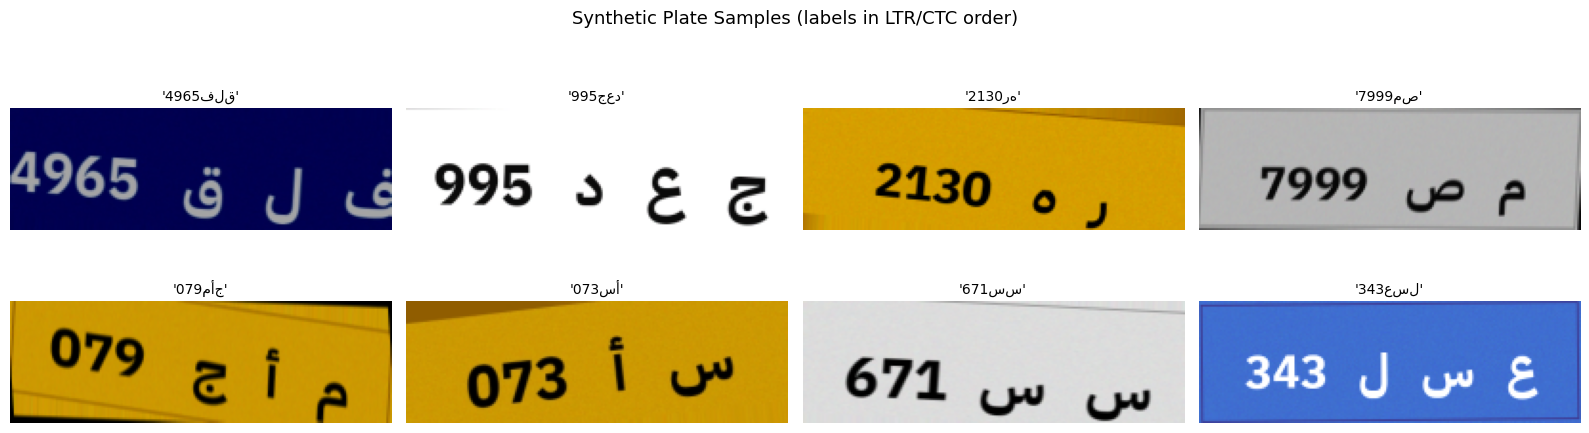


✅ Cell 2 complete — 50,000 synthetic plates generated.


In [2]:
# ============================================================
# CELL 2: V3 Synthetic Plate Generator (Corrected Spacing)
# ============================================================
# Generates 50,000 synthetic Egyptian license plate images
# with proper LTR labeling for CTC, correct font, and
# heavy augmentation per CRNN_Solution_Report.md §4.

from pathlib import Path
import random
import cv2
import numpy as np
import albumentations as A
import json
import time
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

OUTPUT_DIR = Path("/kaggle/working/synthetic_v3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NUM_TRAIN = 40000
NUM_VAL   = 7000
NUM_TEST  = 3000
TOTAL     = NUM_TRAIN + NUM_VAL + NUM_TEST  # 50,000

# ── Plate Visual Config ──
PLATE_CONFIGS = {
    "private": {"bg": (0, 51, 153),     "text": (255, 255, 255)},  # Dark blue bg
    "taxi":    {"bg": (204, 153, 0),     "text": (0, 0, 0)},       # Yellow bg
    "public":  {"bg": (220, 220, 220),   "text": (0, 0, 0)},       # White/grey bg
}
PLATE_TYPES = list(PLATE_CONFIGS.keys())

# Plate image dimensions (before augmentation resize)
PLATE_W = 400
PLATE_H = 128

# Load font at two sizes for variation
font_path = "/kaggle/working/fonts/IBMPlexSansArabic-Bold.ttf"
FONTS = [
    ImageFont.truetype(font_path, size=52),
    ImageFont.truetype(font_path, size=48),
    ImageFont.truetype(font_path, size=56),
]

# ── Augmentation Pipeline (from report §4.2) ──
augment_pipeline = A.Compose([
    # Geometric (simulate camera angles)
    A.Perspective(scale=(0.02, 0.06), p=0.4),
    A.Rotate(limit=7, border_mode=cv2.BORDER_REPLICATE, p=0.5),
    A.Affine(shear={"x": (-4, 4), "y": (-4, 4)}, mode=cv2.BORDER_REPLICATE, p=0.3),

    # Photometric (simulate lighting)
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
    A.GaussNoise(var_limit=(10.0, 40.0), p=0.4),

    # Camera effects
    A.MotionBlur(blur_limit=(3, 5), p=0.25),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.ImageCompression(quality_lower=65, quality_upper=95, p=0.3),

    # Final resize to model input
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
])


def generate_plate_text():
    """Generate random valid Egyptian plate text.
    Format: 2-3 Arabic letters + 3-4 digits.
    """
    num_letters = random.choice([2, 3])
    num_digits = random.choice([3, 4])

    letters = [random.choice(ARABIC_LETTERS) for _ in range(num_letters)]
    digits = [random.choice(DIGITS) for _ in range(num_digits)]

    # 🌟 التعديل تم هنا: مسافات واسعة بين الحروف عشان متتشبكش
    arabic_letters_str = "   ".join(letters)
    digits_str = "".join(digits)

    # 🌟 الـ Label بيفضل من غير مسافات عشان الـ CTC loss يشتغل صح
    ltr_label = digits_str + "".join(letters)
    
    return arabic_letters_str, digits_str, ltr_label


def render_plate_image(arabic_letters, digits_str, plate_type="private"):
    """Render a synthetic plate image using PIL."""
    config = PLATE_CONFIGS[plate_type]
    img = Image.new("RGB", (PLATE_W, PLATE_H), color=config["bg"])
    draw = ImageDraw.Draw(img)
    font = random.choice(FONTS)
    text_color = config["text"]

    # Add slight background texture (noise to make it more realistic)
    pixels = np.array(img)
    noise = np.random.randint(-8, 9, pixels.shape, dtype=np.int16)
    pixels = np.clip(pixels.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(pixels)
    draw = ImageDraw.Draw(img)

    # Add thin border
    border_color = tuple(max(0, c - 60) for c in config["bg"])
    draw.rectangle([2, 2, PLATE_W - 3, PLATE_H - 3], outline=border_color, width=2)

    # ── Layout: [DIGITS gap ARABIC_LETTERS] ──
    digits_text = digits_str
    try:
        d_bbox = draw.textbbox((0, 0), digits_text, font=font)
    except Exception:
        d_bbox = (0, 0, len(digits_text) * 30, 50)
    d_w = d_bbox[2] - d_bbox[0]
    d_h = d_bbox[3] - d_bbox[1]

    letters_text = arabic_letters
    try:
        l_bbox = draw.textbbox((0, 0), letters_text, font=font)
    except Exception:
        l_bbox = (0, 0, len(letters_text) * 35, 50)
    l_w = l_bbox[2] - l_bbox[0]
    l_h = l_bbox[3] - l_bbox[1]

    total_content_w = d_w + l_w + 40  # 40px gap
    start_x = (PLATE_W - total_content_w) // 2
    y_center = (PLATE_H - max(d_h, l_h)) // 2

    # Draw digits
    y_jitter = random.randint(-4, 4)
    digit_x = start_x + random.randint(-5, 5)
    draw.text((digit_x, y_center + y_jitter), digits_text, fill=text_color, font=font)

    # Draw Arabic letters
    letter_x = start_x + d_w + 40 + random.randint(-5, 5)
    draw.text((letter_x, y_center + y_jitter), letters_text, fill=text_color, font=font)

    return np.array(img)


def generate_dataset(num_samples, split_name, start_idx=0):
    split_dir = OUTPUT_DIR / split_name / "images"
    split_dir.mkdir(parents=True, exist_ok=True)

    labels = {}
    for i in range(num_samples):
        idx = start_idx + i
        arabic_letters, digits_str, ltr_label = generate_plate_text()
        plate_type = random.choice(PLATE_TYPES)

        plate_img = render_plate_image(arabic_letters, digits_str, plate_type)
        
        augmented = augment_pipeline(image=plate_img)
        aug_img = augmented["image"]

        filename = f"plate_{idx:06d}.png"
        cv2.imwrite(str(split_dir / filename), cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
        labels[filename] = ltr_label

        if (i + 1) % 5000 == 0:
            print(f"   [{split_name}] Generated {i + 1}/{num_samples}")

    labels_path = OUTPUT_DIR / split_name / "labels.json"
    with open(labels_path, "w", encoding="utf-8") as f:
        json.dump(labels, f, ensure_ascii=False, indent=2)

    return labels


print("🔧 Generating synthetic dataset...")
print(f"   Train: {NUM_TRAIN} | Val: {NUM_VAL} | Test: {NUM_TEST} | Total: {TOTAL}")
print()

t0 = time.time()
train_labels = generate_dataset(NUM_TRAIN, "train", start_idx=0)
print(f"✅ Train set complete: {len(train_labels)} images")

val_labels = generate_dataset(NUM_VAL, "val", start_idx=NUM_TRAIN)
print(f"✅ Val set complete: {len(val_labels)} images")

test_labels = generate_dataset(NUM_TEST, "test", start_idx=NUM_TRAIN + NUM_VAL)
print(f"✅ Test set complete: {len(test_labels)} images")

elapsed = time.time() - t0
print(f"\n🎉 Dataset generation complete in {elapsed:.0f}s")

# ── Verify & Visualize ──
print("\n── Sample labels (LTR for CTC) ──")
for name, label in list(train_labels.items())[:5]:
    print(f"  {name}: '{label}'")

fig, axes = plt.subplots(2, 4, figsize=(16, 5))
sample_files = list((OUTPUT_DIR / "train" / "images").glob("*.png"))[:8]
for ax, fpath in zip(axes.flat, sample_files):
    img = cv2.imread(str(fpath))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label = train_labels[fpath.name]
    ax.imshow(img)
    ax.set_title(f"'{label}'", fontsize=10)
    ax.axis("off")
plt.suptitle("Synthetic Plate Samples (labels in LTR/CTC order)", fontsize=13)
plt.tight_layout()
plt.show()

print("\n✅ Cell 2 complete — 50,000 synthetic plates generated.")

In [3]:
import os
print("📂 العناوين الموجودة عندك في الـ Input هي:")
for dirname, _, _ in os.walk('/kaggle/input'):
    print(dirname)

📂 العناوين الموجودة عندك في الـ Input هي:
/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/machathon-3
/kaggle/input/competitions/machathon-3/train_images
/kaggle/input/competitions/machathon-3/train_bbxs
/kaggle/input/competitions/machathon-3/test_images
/kaggle/input/datasets
/kaggle/input/datasets/nourhanabosaeed
/kaggle/input/datasets/nourhanabosaeed/plates-classification
/kaggle/input/datasets/nourhanabosaeed/plates-classification/plate colors
/kaggle/input/datasets/nourhanabosaeed/plates-classification/plate colors/orange
/kaggle/input/datasets/nourhanabosaeed/plates-classification/plate colors/yellow
/kaggle/input/datasets/nourhanabosaeed/plates-classification/plate colors/blue
/kaggle/input/datasets/nourhanabosaeed/plates-classification/plate colors/red
/kaggle/input/datasets/nourhanabosaeed/plates-classification/plate colors/brown
/kaggle/input/datasets/alyalsayed
/kaggle/input/datasets/alyalsayed/egyptian-car-plates
/kaggle/input/datasets/alyalsayed/egyptia

📦 DATASET 1: Machathon 3.0
  CSV: /kaggle/input/competitions/machathon-3/train_labels.csv
  Raw entries: 5279
  Columns: ['img_name', 'label']
  Image col: 'img_name' | Label col: 'label'
  Image dir: /kaggle/input/competitions/machathon-3/train_images

  Machathon Results:
    total: 5279
    reversed: 5279
    invalid_chars: 3788
    bad_structure: 730
    missing_img: 0
    kept: 761

📦 DATASET 2: Ahmedeko
  CSV: /kaggle/input/datasets/ahmedeko/egypt-cars-plates/dataset/train.csv
  Raw entries: 9947
  Columns: ['name', 'label']
  Image col: 'name' | Label col: 'label'
  Image dir: /kaggle/input/datasets/ahmedeko/egypt-cars-plates/dataset/train

  Ahmedeko Results:
    total: 9947
    mapped: 9947
    unmappable: 0
    bad_structure: 2615
    missing_img: 0
    kept: 7332

🔗 MERGING DATASETS
  Machathon kept: 761
  Ahmedeko kept:  7332
  ─────────────────────
  TOTAL MERGED:   8093

── Character Distribution (merged real data) ──
  '0':   223  ██
  '1':  4011  ███████████████████████

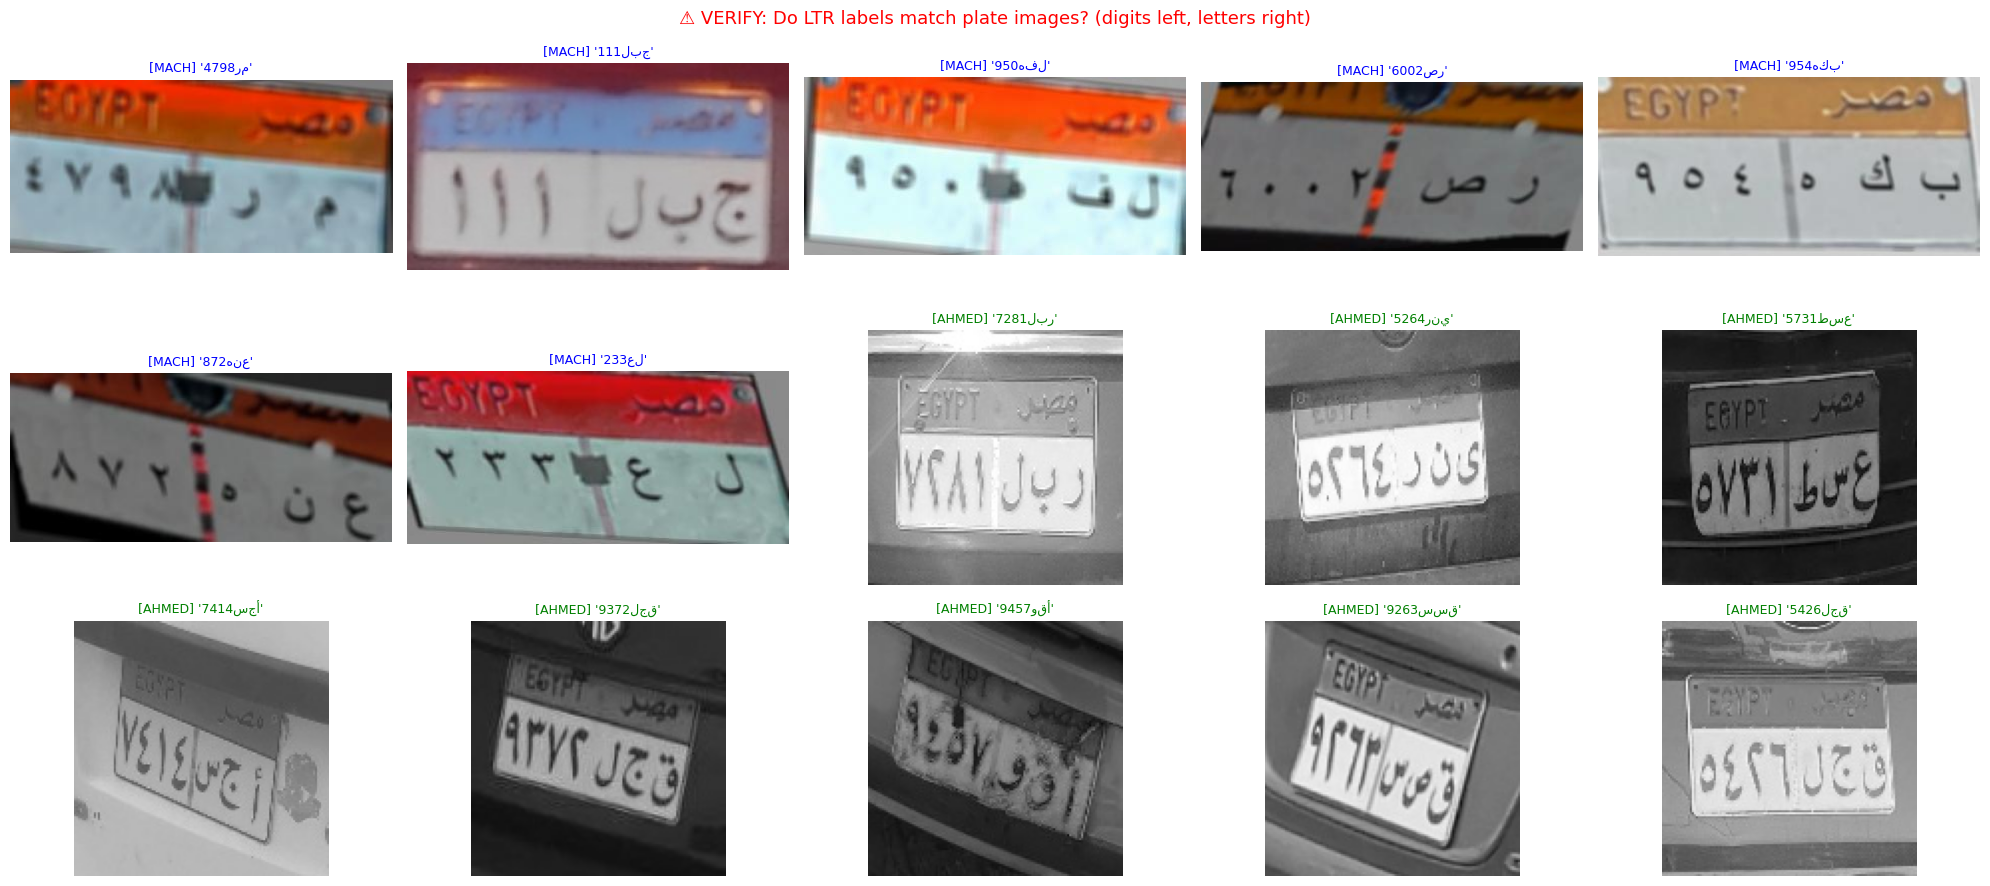


⚠️  MANUALLY CHECK the plot above!
   If digits are wrong, the reversal/mapping needs adjustment.

✅ Cell 5.5 complete — 8093 real images merged.
   Path: /kaggle/working/real_data


In [4]:
# ============================================================
# CELL 5.5: Merge Machathon + Ahmedeko into Unified Dataset
# ============================================================
import pandas as pd
import shutil
import json
import cv2
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# ── Output ──
MERGED_DIR = Path("/kaggle/working/real_data")
MERGED_DIR.mkdir(parents=True, exist_ok=True)
(MERGED_DIR / "images").mkdir(exist_ok=True)

# ── Valid Egyptian Plate Characters ──
VALID_LETTERS = set("أبجدرسصطعفقكلمنهوي")
VALID_DIGITS = set("0123456789")

# ── English → Arabic Mapping (for Ahmedeko) ──
ENG_TO_AR = {
    'A': 'أ', 'B': 'ب', 'J': 'ج', 'G': 'ج',
    'D': 'د', 'R': 'ر', 'S': 'س', 'C': 'س',
    'X': 'ص', 'T': 'ط', 'E': 'ع', 'F': 'ف',
    'Q': 'ق', 'K': 'ك', 'L': 'ل', 'M': 'م',
    'N': 'ن', 'H': 'ه', 'W': 'و', 'O': 'و',
    'Y': 'ي', 'I': 'ي',
}

def validate_plate(label):
    """Strict Egyptian plate validation: 2-3 letters + 3-4 digits."""
    if not label or len(label) < 5 or len(label) > 7:
        return False
    letters = [ch for ch in label if ch in VALID_LETTERS]
    digits = [ch for ch in label if ch in VALID_DIGITS]
    unknown = [ch for ch in label if ch not in VALID_LETTERS and ch not in VALID_DIGITS]
    if unknown:
        return False
    if len(letters) < 2 or len(letters) > 3:
        return False
    if len(digits) < 3 or len(digits) > 4:
        return False
    return True


def ensure_ltr_order(label):
    """Ensure label is in LTR order: digits first, then letters.
    This is what CTC expects since digits are on the left of the plate.
    """
    digits = [ch for ch in label if ch in VALID_DIGITS]
    letters = [ch for ch in label if ch in VALID_LETTERS]
    return "".join(digits) + "".join(letters)


# ==================================================
# DATASET 1: MACHATHON 3.0
# ==================================================
print("=" * 60)
print("📦 DATASET 1: Machathon 3.0")
print("=" * 60)

MACHATHON_DIR = Path("/kaggle/input/competitions/machathon-3")  # ← adjust path if needed

# Auto-detect CSV
csv_candidates = list(MACHATHON_DIR.glob("*.csv"))
mach_csv = None
for c in csv_candidates:
    if "train" in c.name.lower() and "label" in c.name.lower():
        mach_csv = c
        break
if mach_csv is None and csv_candidates:
    mach_csv = csv_candidates[0]

print(f"  CSV: {mach_csv}")
mach_df = pd.read_csv(mach_csv)
print(f"  Raw entries: {len(mach_df)}")
print(f"  Columns: {mach_df.columns.tolist()}")

# Auto-detect columns (image, label)
mach_cols = mach_df.columns.tolist()
mach_img_col = mach_cols[0]
mach_lbl_col = mach_cols[-1]
print(f"  Image col: '{mach_img_col}' | Label col: '{mach_lbl_col}'")

# Auto-detect image folder
mach_img_dir = None
for folder in ["train", "images", "train_images", ""]:
    candidate = MACHATHON_DIR / folder if folder else MACHATHON_DIR
    if candidate.is_dir() and any(candidate.glob("*.jpg")) or any(candidate.glob("*.png")):
        mach_img_dir = candidate
        break
if mach_img_dir is None:
    # Try any subfolder with images
    for sub in MACHATHON_DIR.iterdir():
        if sub.is_dir():
            imgs = list(sub.glob("*.*"))
            if len(imgs) > 100:
                mach_img_dir = sub
                break
print(f"  Image dir: {mach_img_dir}")

# Process Machathon labels
mach_labels = {}
mach_stats = {"total": 0, "reversed": 0, "invalid_chars": 0,
              "bad_structure": 0, "missing_img": 0, "kept": 0}

for _, row in mach_df.iterrows():
    mach_stats["total"] += 1
    img_id = str(row[mach_img_col]).strip()
    raw_label = str(row[mach_lbl_col]).strip()

    # Step 1: Reverse RTL → LTR
    reversed_label = raw_label[::-1]
    mach_stats["reversed"] += 1

    # Step 2: Check for non-Egyptian characters
    has_invalid = any(
        ch not in VALID_LETTERS and ch not in VALID_DIGITS and ch != ' '
        for ch in reversed_label
    )
    if has_invalid:
        mach_stats["invalid_chars"] += 1
        continue

    # Step 3: Clean (remove spaces) and reorder to digits-first LTR
    clean_label = reversed_label.replace(" ", "")
    ltr_label = ensure_ltr_order(clean_label)

    # Step 4: Validate plate structure
    if not validate_plate(ltr_label):
        mach_stats["bad_structure"] += 1
        continue

    # Step 5: Find the actual image file
    img_path = None
    for ext in ["", ".jpg", ".png", ".jpeg", ".JPG", ".PNG"]:
        candidate = mach_img_dir / f"{img_id}{ext}"
        if candidate.exists():
            img_path = candidate
            break
    if img_path is None:
        mach_stats["missing_img"] += 1
        continue

    # Step 6: Copy image with prefix to avoid name collisions
    dst_name = f"mach_{img_path.name}"
    shutil.copy2(img_path, MERGED_DIR / "images" / dst_name)
    mach_labels[dst_name] = ltr_label
    mach_stats["kept"] += 1

print(f"\n  Machathon Results:")
for k, v in mach_stats.items():
    print(f"    {k}: {v}")


# ==================================================
# DATASET 2: AHMEDEKO
# ==================================================
print("\n" + "=" * 60)
print("📦 DATASET 2: Ahmedeko")
print("=" * 60)

AHMEDEKO_DIR = Path("/kaggle/input/datasets/ahmedeko/egypt-cars-plates")  # ← adjust path if needed

# Auto-detect CSV
csv_candidates = list(AHMEDEKO_DIR.rglob("*.csv"))
ahmed_csv = None
for c in csv_candidates:
    if "train" in c.name.lower() or "label" in c.name.lower():
        ahmed_csv = c
        break
if ahmed_csv is None and csv_candidates:
    ahmed_csv = csv_candidates[0]

print(f"  CSV: {ahmed_csv}")
ahmed_df = pd.read_csv(ahmed_csv)
print(f"  Raw entries: {len(ahmed_df)}")
print(f"  Columns: {ahmed_df.columns.tolist()}")

ahmed_cols = ahmed_df.columns.tolist()
ahmed_img_col = ahmed_cols[0]
ahmed_lbl_col = ahmed_cols[-1]
print(f"  Image col: '{ahmed_img_col}' | Label col: '{ahmed_lbl_col}'")

# Auto-detect image folder
ahmed_img_dir = None
for folder_name in ["images", "train", "train_images", "merged_plates", ""]:
    for root_candidate in [AHMEDEKO_DIR, *[d for d in AHMEDEKO_DIR.iterdir() if d.is_dir()]]:
        candidate = root_candidate / folder_name if folder_name else root_candidate
        if candidate.is_dir():
            imgs = list(candidate.glob("*.*"))[:5]
            if imgs:
                ahmed_img_dir = candidate
                break
    if ahmed_img_dir:
        break
print(f"  Image dir: {ahmed_img_dir}")

# Process Ahmedeko labels
ahmed_labels = {}
ahmed_stats = {"total": 0, "mapped": 0, "unmappable": 0,
               "bad_structure": 0, "missing_img": 0, "kept": 0}

for _, row in ahmed_df.iterrows():
    ahmed_stats["total"] += 1
    img_id = str(row[ahmed_img_col]).strip()
    raw_label = str(row[ahmed_lbl_col]).strip().upper()

    # Step 1: Map English → Arabic (digits stay as-is)
    arabic_label = ""
    unmappable = False
    for ch in raw_label:
        if ch.isdigit():
            arabic_label += ch
        elif ch in ENG_TO_AR:
            arabic_label += ENG_TO_AR[ch]
        else:
            # Unknown English char → can't map → drop
            unmappable = True
            break

    if unmappable:
        ahmed_stats["unmappable"] += 1
        continue
    ahmed_stats["mapped"] += 1

    # Step 2: Reorder to digits-first LTR (Ahmedeko is already LTR)
    ltr_label = ensure_ltr_order(arabic_label)

    # Step 3: Validate
    if not validate_plate(ltr_label):
        ahmed_stats["bad_structure"] += 1
        continue

    # Step 4: Find image
    img_path = None
    for ext in ["", ".jpg", ".png", ".jpeg", ".JPG", ".PNG"]:
        candidate = ahmed_img_dir / f"{img_id}{ext}"
        if candidate.exists():
            img_path = candidate
            break
    if img_path is None:
        ahmed_stats["missing_img"] += 1
        continue

    # Step 5: Copy with prefix
    dst_name = f"ahmed_{img_path.name}"
    shutil.copy2(img_path, MERGED_DIR / "images" / dst_name)
    ahmed_labels[dst_name] = ltr_label
    ahmed_stats["kept"] += 1

print(f"\n  Ahmedeko Results:")
for k, v in ahmed_stats.items():
    print(f"    {k}: {v}")


# ==================================================
# MERGE & SAVE
# ==================================================
print("\n" + "=" * 60)
print("🔗 MERGING DATASETS")
print("=" * 60)

all_labels = {**mach_labels, **ahmed_labels}
with open(MERGED_DIR / "labels.json", "w", encoding="utf-8") as f:
    json.dump(all_labels, f, ensure_ascii=False, indent=2)

print(f"  Machathon kept: {len(mach_labels)}")
print(f"  Ahmedeko kept:  {len(ahmed_labels)}")
print(f"  ─────────────────────")
print(f"  TOTAL MERGED:   {len(all_labels)}")

# Character distribution
all_chars = "".join(all_labels.values())
char_counts = Counter(all_chars)
print(f"\n── Character Distribution (merged real data) ──")
CHARSET_CHECK = list("0123456789أبجدرسصطعفقكلمنهوي")
for ch in CHARSET_CHECK:
    count = char_counts.get(ch, 0)
    bar = "█" * (count // 100)
    print(f"  '{ch}': {count:>5}  {bar}")

# Label length distribution
lengths = Counter(len(v) for v in all_labels.values())
print(f"\n── Label Length Distribution ──")
for length in sorted(lengths.keys()):
    print(f"  Length {length}: {lengths[length]} plates")

# ── Visual Spot Check ──
fig, axes = plt.subplots(3, 5, figsize=(20, 9))
# Show mix of both datasets
mach_samples = list(mach_labels.items())[:7]
ahmed_samples = list(ahmed_labels.items())[:8]
all_samples = mach_samples + ahmed_samples

for ax, (fname, label) in zip(axes.flat, all_samples):
    img_path = MERGED_DIR / "images" / fname
    if img_path.exists():
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        source = "MACH" if fname.startswith("mach_") else "AHMED"
        ax.set_title(f"[{source}] '{label}'", fontsize=9,
                     color="blue" if source == "MACH" else "green")
    ax.axis("off")

plt.suptitle("⚠️ VERIFY: Do LTR labels match plate images? (digits left, letters right)",
             fontsize=13, color="red")
plt.tight_layout()
plt.show()

print("\n⚠️  MANUALLY CHECK the plot above!")
print("   If digits are wrong, the reversal/mapping needs adjustment.")
print(f"\n✅ Cell 5.5 complete — {len(all_labels)} real images merged.")
print(f"   Path: {MERGED_DIR}")


In [5]:
# ================================================================
# ### CELL 4.5 ### — NEW: Stratified 80/20 Split of Real Data
# ================================================================
# This cell MUST run AFTER Cell 4 (which creates the unified real
# dataset) and BEFORE the training cell.
#
# It creates:
#   - real_train_samples (80%) → used for mixed training
#   - real_test_samples  (20%) → LOCKED for final evaluation only

import random
import json
import shutil
from pathlib import Path
from collections import Counter

SPLIT_SEED = 42
random.seed(SPLIT_SEED)

# ---- Configuration ----
# FIXED PATH: Now pointing to the exact folder found by the debugger
UNIFIED_REAL_DIR = Path("/kaggle/working/real_data")  
REAL_TRAIN_DIR   = Path("/kaggle/working/real_train_80")
REAL_TEST_DIR    = Path("/kaggle/working/real_test_20")


def get_plate_type(label):
    """Classify plate format for stratification (e.g., L2_D4, L3_D3)."""
    letters = sum(1 for c in label if not c.isdigit())
    digits  = sum(1 for c in label if c.isdigit())
    return f"L{letters}_D{digits}"


def load_real_samples(data_dir):
    """Load all (filename, label) pairs from the unified real dataset."""
    labels_path = data_dir / "labels.json"
    image_dir   = data_dir / "images"
    
    with open(labels_path, "r", encoding="utf-8") as f:
        labels = json.load(f)
    
    samples = [
        (fn, label) for fn, label in labels.items()
        if (image_dir / fn).exists()
    ]
    print(f"Loaded {len(samples)} real images from {data_dir}")
    return samples


def stratified_split(samples, test_ratio=0.20):
    """
    Split samples into train/test with proportional representation
    of each plate format (2-letter+3-digit, 3-letter+4-digit, etc.).
    """
    random.seed(SPLIT_SEED)
    
    groups = {}
    for sample in samples:
        ptype = get_plate_type(sample[1])
        groups.setdefault(ptype, []).append(sample)
    
    train_set, test_set = [], []
    
    for ptype, group in groups.items():
        random.shuffle(group)
        n_test = max(1, int(len(group) * test_ratio))
        test_set.extend(group[:n_test])
        train_set.extend(group[n_test:])
    
    random.shuffle(train_set)
    random.shuffle(test_set)
    
    return train_set, test_set


def save_split(samples, src_dir, dst_dir):
    """Copy images and write labels.json for a split."""
    dst_dir.mkdir(parents=True, exist_ok=True)
    img_dst = dst_dir / "images"
    img_dst.mkdir(exist_ok=True)
    
    labels_dict = {}
    for fn, label in samples:
        src_img = src_dir / "images" / fn
        dst_img = img_dst / fn
        if src_img.exists():
            shutil.copy2(str(src_img), str(dst_img))
            labels_dict[fn] = label
    
    with open(dst_dir / "labels.json", "w", encoding="utf-8") as f:
        json.dump(labels_dict, f, ensure_ascii=False, indent=2)
    
    print(f"  Saved {len(labels_dict)} images to {dst_dir}")


# ---- Execute the split ----
all_real = load_real_samples(UNIFIED_REAL_DIR)
real_train_samples, real_test_samples = stratified_split(all_real, test_ratio=0.20)

print(f"\n{'='*55}")
print(f"  TRAIN (80%): {len(real_train_samples)} images")
print(f"  TEST  (20%): {len(real_test_samples)} images  🔒 LOCKED")
print(f"{'='*55}")

# Show stratification balance
train_types = Counter(get_plate_type(s[1]) for s in real_train_samples)
test_types  = Counter(get_plate_type(s[1]) for s in real_test_samples)
print(f"\nTrain plate types: {dict(train_types)}")
print(f"Test  plate types: {dict(test_types)}")

# Save to disk
save_split(real_train_samples, UNIFIED_REAL_DIR, REAL_TRAIN_DIR)
save_split(real_test_samples,  UNIFIED_REAL_DIR, REAL_TEST_DIR)

print(f"\n✅ Train: {REAL_TRAIN_DIR}")
print(f"🔒 Test:  {REAL_TEST_DIR}  ← DO NOT TOUCH until final evaluation!")

Loaded 8093 real images from /kaggle/working/real_data

  TRAIN (80%): 6477 images
  TEST  (20%): 1616 images  🔒 LOCKED

Train plate types: {'L3_D4': 5995, 'L2_D3': 152, 'L2_D4': 192, 'L3_D3': 138}
Test  plate types: {'L3_D4': 1498, 'L2_D4': 47, 'L3_D3': 34, 'L2_D3': 37}
  Saved 6477 images to /kaggle/working/real_train_80
  Saved 1616 images to /kaggle/working/real_test_20

✅ Train: /kaggle/working/real_train_80
🔒 Test:  /kaggle/working/real_test_20  ← DO NOT TOUCH until final evaluation!


In [6]:
# ============================================================
# EALPR V4 replacement cells
# Paste these cells after your real_data -> real_train_80/real_test_20
# split cell. They replace the old PlateOCR_V3 CTC architecture,
# mixed training cell, fine-tune cell, and locked-test evaluation cell.
# ============================================================

# ============================================================
# CELL V4.1: Slot Dataset, Transforms, Metrics
# ============================================================
import json
import math
import random
import time
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.auto import tqdm

SEED = globals().get("SEED", 42)
SPLIT_SEED = globals().get("SPLIT_SEED", 42)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ARABIC_LETTERS = list("أبجدرسصطعفقكلمنهوي")
DIGITS = list("0123456789")
DIGIT_PAD = len(DIGITS)          # 10
LETTER_PAD = len(ARABIC_LETTERS) # 20

IMG_HEIGHT_V4 = 96
IMG_WIDTH_V4 = 320
BATCH_SIZE_V4 = 48
NUM_WORKERS = 2

SYNTH_TRAIN_DIR = Path("/kaggle/working/synthetic_v3/train")
REAL_TRAIN_DIR = Path(globals().get("REAL_TRAIN_DIR", "/kaggle/working/real_train_80"))
REAL_TEST_DIR = Path(globals().get("REAL_TEST_DIR", "/kaggle/working/real_test_20"))


def normalize_plate_label(label):
    label = str(label).strip().replace(" ", "")
    digits = [ch for ch in label if ch in DIGITS]
    letters = [ch for ch in label if ch in ARABIC_LETTERS]
    return "".join(digits) + "".join(letters)


def is_valid_slot_label(label):
    label = normalize_plate_label(label)
    d = sum(ch in DIGITS for ch in label)
    l = sum(ch in ARABIC_LETTERS for ch in label)
    return d in (3, 4) and l in (2, 3) and len(label) == d + l


def label_to_targets(label):
    label = normalize_plate_label(label)
    digits = [DIGITS.index(ch) for ch in label if ch in DIGITS]
    letters = [ARABIC_LETTERS.index(ch) for ch in label if ch in ARABIC_LETTERS]

    digit_targets = digits + [DIGIT_PAD] * (4 - len(digits))
    letter_targets = letters + [LETTER_PAD] * (3 - len(letters))
    digit_len_target = len(digits) - 3   # 0 -> 3 digits, 1 -> 4 digits
    letter_len_target = len(letters) - 2 # 0 -> 2 letters, 1 -> 3 letters

    return (
        torch.tensor(digit_targets, dtype=torch.long),
        torch.tensor(letter_targets, dtype=torch.long),
        torch.tensor(digit_len_target, dtype=torch.long),
        torch.tensor(letter_len_target, dtype=torch.long),
    )


class PlateSlotDataset(Dataset):
    def __init__(self, data_dir, transform=None, strict=True):
        self.data_dir = Path(data_dir)
        self.image_dir = self.data_dir / "images"
        self.transform = transform
        labels_path = self.data_dir / "labels.json"

        with open(labels_path, "r", encoding="utf-8") as f:
            raw_labels = json.load(f)

        self.samples = []
        dropped = 0
        for fn in sorted(raw_labels.keys()):
            img_path = self.image_dir / fn
            label = normalize_plate_label(raw_labels[fn])
            if not img_path.exists() or not is_valid_slot_label(label):
                dropped += 1
                if strict and img_path.exists():
                    print(f"Skipping invalid label: {fn} -> {raw_labels[fn]}")
                continue
            self.samples.append((fn, label))

        print(f"PlateSlotDataset: {len(self.samples)} kept, {dropped} dropped from {self.data_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fn, label = self.samples[idx]
        img = cv2.imread(str(self.image_dir / fn), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(str(self.image_dir / fn))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = self.transform(image=img)["image"]
        else:
            img = cv2.resize(img, (IMG_WIDTH_V4, IMG_HEIGHT_V4))
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        digit_t, letter_t, digit_len_t, letter_len_t = label_to_targets(label)
        return img, digit_t, letter_t, digit_len_t, letter_len_t, label


def slot_collate_fn(batch):
    images, digit_t, letter_t, digit_len_t, letter_len_t, labels = zip(*batch)
    return (
        torch.stack(images, dim=0),
        torch.stack(digit_t, dim=0),
        torch.stack(letter_t, dim=0),
        torch.stack(digit_len_t, dim=0),
        torch.stack(letter_len_t, dim=0),
        list(labels),
    )


train_transform_v4 = A.Compose([
    A.Resize(height=IMG_HEIGHT_V4, width=IMG_WIDTH_V4),
    A.Perspective(scale=(0.015, 0.06), p=0.45),
    A.Rotate(limit=5, border_mode=cv2.BORDER_REPLICATE, p=0.45),
    A.Affine(shear=(-4, 4), mode=cv2.BORDER_REPLICATE, p=0.25),
    A.RandomBrightnessContrast(brightness_limit=0.28, contrast_limit=0.28, p=0.70),
    A.HueSaturationValue(hue_shift_limit=4, sat_shift_limit=18, val_shift_limit=12, p=0.25),
    A.GaussNoise(var_limit=(5.0, 45.0), p=0.35),
    A.MotionBlur(blur_limit=5, p=0.20),
    A.GaussianBlur(blur_limit=3, p=0.15),
    A.ImageCompression(quality_lower=55, quality_upper=95, p=0.25),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), max_pixel_value=255.0),
    ToTensorV2(),
])

val_transform_v4 = A.Compose([
    A.Resize(height=IMG_HEIGHT_V4, width=IMG_WIDTH_V4),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5), max_pixel_value=255.0),
    ToTensorV2(),
])


def stratified_indices(samples, val_ratio=0.12, seed=42):
    groups = defaultdict(list)
    for idx, (_, label) in enumerate(samples):
        d = sum(ch in DIGITS for ch in label)
        l = sum(ch in ARABIC_LETTERS for ch in label)
        groups[f"D{d}_L{l}"].append(idx)

    rng = random.Random(seed)
    train_idx, val_idx = [], []
    for _, idxs in groups.items():
        rng.shuffle(idxs)
        n_val = max(1, int(round(len(idxs) * val_ratio))) if len(idxs) > 1 else 0
        val_idx.extend(idxs[:n_val])
        train_idx.extend(idxs[n_val:])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    return train_idx, val_idx


def levenshtein(a, b):
    dp = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        prev, dp[0] = dp[0], i
        for j, cb in enumerate(b, 1):
            old = dp[j]
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + (ca != cb))
            prev = old
    return dp[-1]


# ============================================================


/tmp/ipykernel_57/3490516869.py:145: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  A.Affine(shear=(-4, 4), mode=cv2.BORDER_REPLICATE, p=0.25),
/tmp/ipykernel_57/3490516869.py:148: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 45.0), p=0.35),
/tmp/ipykernel_57/3490516869.py:151: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=55, quality_upper=95, p=0.25),


In [7]:
# CELL V4.2: Grammar-Aware Slot Transformer Model
# ============================================================
class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = ConvBNAct(in_ch, out_ch, 3, stride, 1)
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.drop = nn.Dropout2d(dropout)
        self.skip = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        y = self.conv1(x)
        y = self.drop(self.conv2(y))
        return F.silu(y + self.skip(x), inplace=True)


class PlateSlotTransformer(nn.Module):
    def __init__(self, d_model=256, nhead=8, enc_layers=4, dec_layers=2, dropout=0.15):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBNAct(3, 48, stride=2),                 # 96x320 -> 48x160
            ResidualBlock(48, 64, stride=(2, 2), dropout=0.03),   # 24x80
            ResidualBlock(64, 96, stride=(2, 1), dropout=0.04),   # 12x80
            ResidualBlock(96, 160, stride=(2, 1), dropout=0.05),  # 6x80
            ResidualBlock(160, d_model, stride=(2, 1), dropout=0.05), # 3x80
            ConvBNAct(d_model, d_model),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, 128, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=enc_layers)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=dec_layers)
        self.slot_queries = nn.Embedding(7, d_model)
        self.norm = nn.LayerNorm(d_model)

        self.digit_head = nn.Linear(d_model, len(DIGITS) + 1)
        self.letter_head = nn.Linear(d_model, len(ARABIC_LETTERS) + 1)
        self.digit_len_head = nn.Linear(d_model, 2)
        self.letter_len_head = nn.Linear(d_model, 2)

    def forward(self, x):
        feat = self.cnn(x)                 # B,C,H,W
        seq = feat.mean(dim=2).transpose(1, 2)  # B,T,C
        t = seq.size(1)
        pos = self.pos_embed
        if t != pos.size(1):
            pos = F.interpolate(pos.transpose(1, 2), size=t, mode="linear", align_corners=False).transpose(1, 2)
        memory = self.encoder(seq + pos[:, :t, :])

        pooled = memory.mean(dim=1)
        queries = self.slot_queries.weight.unsqueeze(0).expand(x.size(0), -1, -1)
        slots = self.norm(self.decoder(queries, memory))

        return {
            "digit_logits": self.digit_head(slots[:, :4, :]),
            "letter_logits": self.letter_head(slots[:, 4:, :]),
            "digit_len_logits": self.digit_len_head(pooled),
            "letter_len_logits": self.letter_len_head(pooled),
        }


def slot_loss(outputs, digit_t, letter_t, digit_len_t, letter_len_t):
    d_loss = F.cross_entropy(
        outputs["digit_logits"].reshape(-1, len(DIGITS) + 1),
        digit_t.reshape(-1),
        label_smoothing=0.02,
    )
    l_loss = F.cross_entropy(
        outputs["letter_logits"].reshape(-1, len(ARABIC_LETTERS) + 1),
        letter_t.reshape(-1),
        label_smoothing=0.02,
    )
    dl_loss = F.cross_entropy(outputs["digit_len_logits"], digit_len_t)
    ll_loss = F.cross_entropy(outputs["letter_len_logits"], letter_len_t)
    return d_loss + l_loss + 0.35 * (dl_loss + ll_loss)


@torch.no_grad()
def decode_slot_outputs(outputs):
    digit_logits = outputs["digit_logits"]
    letter_logits = outputs["letter_logits"]
    digit_lens = outputs["digit_len_logits"].argmax(dim=1) + 3
    letter_lens = outputs["letter_len_logits"].argmax(dim=1) + 2

    preds = []
    for i in range(digit_logits.size(0)):
        d_len = int(digit_lens[i].item())
        l_len = int(letter_lens[i].item())
        # During decoding, selected slots are forced to real symbols, not PAD.
        d_ids = digit_logits[i, :d_len, :len(DIGITS)].argmax(dim=1).tolist()
        l_ids = letter_logits[i, :l_len, :len(ARABIC_LETTERS)].argmax(dim=1).tolist()
        preds.append("".join(DIGITS[j] for j in d_ids) + "".join(ARABIC_LETTERS[j] for j in l_ids))
    return preds


@torch.no_grad()
def evaluate_slot_model(model, loader, device):
    model.eval()
    total, correct, total_cer = 0, 0, 0.0
    errors = []
    per_char = defaultdict(lambda: {"total": 0, "errors": 0})

    for images, digit_t, letter_t, digit_len_t, letter_len_t, labels in loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = decode_slot_outputs(outputs)

        for pred, gt in zip(preds, labels):
            total += 1
            correct += int(pred == gt)
            dist = levenshtein(pred, gt)
            total_cer += dist / max(len(gt), 1)
            if pred != gt:
                errors.append({"ground_truth": gt, "prediction": pred, "edit_distance": dist})
            for j, ch in enumerate(gt):
                per_char[ch]["total"] += 1
                if j >= len(pred) or pred[j] != ch:
                    per_char[ch]["errors"] += 1

    return {
        "exact": correct / max(total, 1),
        "cer": total_cer / max(total, 1),
        "total": total,
        "errors": errors,
        "per_char": per_char,
    }


model = PlateSlotTransformer().to(DEVICE)
print(f"V4 model ready on {DEVICE}. Parameters: {sum(p.numel() for p in model.parameters()):,}")


# ============================================================


/tmp/ipykernel_57/1668841991.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=enc_layers)


V4 model ready on cuda. Parameters: 7,500,306


In [ ]:
# CELL V4.3: Mixed Training + Real Fine-Tuning
# ============================================================
synthetic_aug = PlateSlotDataset(SYNTH_TRAIN_DIR, transform=train_transform_v4, strict=False)
real_aug = PlateSlotDataset(REAL_TRAIN_DIR, transform=train_transform_v4, strict=False)
real_eval = PlateSlotDataset(REAL_TRAIN_DIR, transform=val_transform_v4, strict=False)

train_idx, val_idx = stratified_indices(real_aug.samples, val_ratio=0.12, seed=SPLIT_SEED)
real_train_subset = Subset(real_aug, train_idx)
real_val_subset = Subset(real_eval, val_idx)

internal_val_loader = DataLoader(
    real_val_subset, batch_size=BATCH_SIZE_V4, shuffle=False,
    collate_fn=slot_collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)


def make_mixed_loader(real_ratio):
    combined = ConcatDataset([synthetic_aug, real_train_subset])
    n_syn = len(synthetic_aug)
    n_real = len(real_train_subset)
    weights = torch.DoubleTensor(
        [(1.0 - real_ratio) / max(n_syn, 1)] * n_syn +
        [real_ratio / max(n_real, 1)] * n_real
    )
    samples_per_epoch = max(BATCH_SIZE_V4 * 220, n_real * 4)
    sampler = WeightedRandomSampler(weights, num_samples=samples_per_epoch, replacement=True)
    return DataLoader(
        combined, batch_size=BATCH_SIZE_V4, sampler=sampler, drop_last=True,
        collate_fn=slot_collate_fn, num_workers=NUM_WORKERS, pin_memory=True
    )


real_only_loader = DataLoader(
    real_train_subset, batch_size=BATCH_SIZE_V4, shuffle=True, drop_last=True,
    collate_fn=slot_collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)


def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, desc):
    model.train()
    losses = []
    pbar = tqdm(loader, desc=desc)
    for images, digit_t, letter_t, digit_len_t, letter_len_t, _ in pbar:
        images = images.to(device, non_blocking=True)
        digit_t = digit_t.to(device, non_blocking=True)
        letter_t = letter_t.to(device, non_blocking=True)
        digit_len_t = digit_len_t.to(device, non_blocking=True)
        letter_len_t = letter_len_t.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = slot_loss(outputs, digit_t, letter_t, digit_len_t, letter_len_t)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        losses.append(float(loss.item()))
        pbar.set_postfix(loss=f"{np.mean(losses[-50:]):.4f}")
    return float(np.mean(losses))


MIXED_EPOCHS = 35
REAL_FT_EPOCHS = 18
CHECKPOINT_V4 = "/kaggle/working/best_ealpr_v4_slot_transformer.pth"

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=2e-4)
first_loader = make_mixed_loader(real_ratio=0.50)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=3e-4, epochs=MIXED_EPOCHS,
    steps_per_epoch=len(first_loader), pct_start=0.12, div_factor=10.0, final_div_factor=30.0
)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

best_val = 0.0
print(f"Real train: {len(real_train_subset)} | internal val: {len(real_val_subset)} | synthetic: {len(synthetic_aug)}")

for epoch in range(1, MIXED_EPOCHS + 1):
    real_ratio = 0.45 + (0.35 * (epoch - 1) / max(MIXED_EPOCHS - 1, 1))
    train_loader = make_mixed_loader(real_ratio=real_ratio)
    avg_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE,
        desc=f"V4 mixed {epoch}/{MIXED_EPOCHS} real={real_ratio:.2f}"
    )
    metrics = evaluate_slot_model(model, internal_val_loader, DEVICE)
    print(f"Epoch {epoch}: loss={avg_loss:.4f} | val_exact={metrics['exact']:.2%} | val_CER={metrics['cer']:.4f}")

    if metrics["exact"] > best_val:
        best_val = metrics["exact"]
        torch.save({
            "epoch": epoch,
            "stage": "mixed",
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "internal_val_exact": metrics["exact"],
            "internal_val_cer": metrics["cer"],
            "img_height": IMG_HEIGHT_V4,
            "img_width": IMG_WIDTH_V4,
            "digits": DIGITS,
            "arabic_letters": ARABIC_LETTERS,
        }, CHECKPOINT_V4)
        print(f"Saved new best mixed checkpoint: {best_val:.2%}")


checkpoint = torch.load(CHECKPOINT_V4, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = optim.AdamW(model.parameters(), lr=7e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=7e-5, epochs=REAL_FT_EPOCHS,
    steps_per_epoch=len(real_only_loader), pct_start=0.20, div_factor=5.0, final_div_factor=20.0
)

for epoch in range(1, REAL_FT_EPOCHS + 1):
    avg_loss = train_one_epoch(
        model, real_only_loader, optimizer, scheduler, scaler, DEVICE,
        desc=f"V4 real-ft {epoch}/{REAL_FT_EPOCHS}"
    )
    metrics = evaluate_slot_model(model, internal_val_loader, DEVICE)
    print(f"FT epoch {epoch}: loss={avg_loss:.4f} | val_exact={metrics['exact']:.2%} | val_CER={metrics['cer']:.4f}")

    if metrics["exact"] > best_val:
        best_val = metrics["exact"]
        torch.save({
            "epoch": epoch,
            "stage": "real_finetune",
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "internal_val_exact": metrics["exact"],
            "internal_val_cer": metrics["cer"],
            "img_height": IMG_HEIGHT_V4,
            "img_width": IMG_WIDTH_V4,
            "digits": DIGITS,
            "arabic_letters": ARABIC_LETTERS,
        }, CHECKPOINT_V4)
        print(f"Saved new best real-ft checkpoint: {best_val:.2%}")

print(f"Training complete. Best internal validation exact match: {best_val:.2%}")
print(f"Best checkpoint: {CHECKPOINT_V4}")


# ============================================================


PlateSlotDataset: 40000 kept, 0 dropped from /kaggle/working/synthetic_v3/train
PlateSlotDataset: 6477 kept, 0 dropped from /kaggle/working/real_train_80
PlateSlotDataset: 6477 kept, 0 dropped from /kaggle/working/real_train_80
Real train: 5700 | internal val: 777 | synthetic: 40000


/tmp/ipykernel_57/3597410625.py:78: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


V4 mixed 1/35 real=0.45:   0%|          | 0/475 [00:00<?, ?it/s]

/tmp/ipykernel_57/3597410625.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 1: loss=5.2751 | val_exact=0.00% | val_CER=0.8373


...

Epoch 30: loss=0.3745 | val_exact=90.99% | val_CER=0.0209
Saved new best mixed checkpoint: 90.99%


V4 mixed 31/35 real=0.76:   0%|          | 0/475 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d20bea86de0>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d20bea86de0>    
self._shutdown_workers()^ 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

    if w.is_alive():  
          ^ ^ ^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'
 ^
   File "/usr/lib/py

Epoch 31: loss=0.3666 | val_exact=90.22% | val_CER=0.0214


V4 mixed 32/35 real=0.77:   0%|          | 0/475 [00:00<?, ?it/s]

In [ ]:
# CELL V4.4: Locked Test Evaluation
# Run once after training. Do not tune from this number.
# ============================================================
import datetime

CHECKPOINT_V4 = "/kaggle/working/best_ealpr_v4_slot_transformer.pth"
checkpoint = torch.load(CHECKPOINT_V4, map_location=DEVICE)
model = PlateSlotTransformer().to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

locked_test_ds = PlateSlotDataset(REAL_TEST_DIR, transform=val_transform_v4, strict=False)
locked_test_loader = DataLoader(
    locked_test_ds, batch_size=BATCH_SIZE_V4, shuffle=False,
    collate_fn=slot_collate_fn, num_workers=NUM_WORKERS, pin_memory=True
)

test_metrics = evaluate_slot_model(model, locked_test_loader, DEVICE)
print("=" * 70)
print("LOCKED REAL TEST RESULTS - EALPR V4 SLOT TRANSFORMER")
print("=" * 70)
print(f"Checkpoint stage:        {checkpoint.get('stage')}")
print(f"Checkpoint epoch:        {checkpoint.get('epoch')}")
print(f"Internal val exact:      {checkpoint.get('internal_val_exact', 0.0):.2%}")
print(f"Internal val CER:        {checkpoint.get('internal_val_cer', 1.0):.4f}")
print(f"Locked test size:        {test_metrics['total']}")
print(f"Locked exact accuracy:   {test_metrics['exact']:.2%}")
print(f"Locked CER:              {test_metrics['cer']:.4f}")
print(f"Total errors:            {len(test_metrics['errors'])}")
print("=" * 70)

print("\nWorst per-character error rates:")
char_rows = sorted(
    test_metrics["per_char"].items(),
    key=lambda kv: -(kv[1]["errors"] / max(kv[1]["total"], 1))
)
for ch, stats in char_rows[:20]:
    rate = stats["errors"] / max(stats["total"], 1)
    print(f"{ch}  {rate:6.2%}  ({stats['errors']}/{stats['total']})")

print("\nWorst 25 plate errors:")
for err in sorted(test_metrics["errors"], key=lambda e: -e["edit_distance"])[:25]:
    print(f"GT: {err['ground_truth']:>8}  ->  Pred: {err['prediction']:<8}  dist={err['edit_distance']}")

results = {
    "timestamp": datetime.datetime.now().isoformat(),
    "methodology": "EALPR V4 grammar-aware slot transformer; fixed-format digit/letter slots; locked 20% real test",
    "checkpoint": CHECKPOINT_V4,
    "checkpoint_stage": checkpoint.get("stage"),
    "checkpoint_epoch": checkpoint.get("epoch"),
    "internal_val_exact": round(float(checkpoint.get("internal_val_exact", 0.0)), 4),
    "internal_val_cer": round(float(checkpoint.get("internal_val_cer", 1.0)), 4),
    "test_set_size": int(test_metrics["total"]),
    "locked_exact_accuracy": round(float(test_metrics["exact"]), 4),
    "locked_cer": round(float(test_metrics["cer"]), 4),
    "num_errors": len(test_metrics["errors"]),
    "errors_sample": test_metrics["errors"][:100],
    "per_char_error_rates": {
        ch: round(stats["errors"] / max(stats["total"], 1), 4)
        for ch, stats in test_metrics["per_char"].items()
    },
}

results_path = "/kaggle/working/ealpr_v4_locked_test_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f"\nSaved detailed results to: {results_path}")
